# Notebook 1: Dataset Preparation & YOLO26n Fine-Tuning

This notebook covers the first stage of the document layout detection pipeline for Hailo-8L:

1. **Document type selection** — Choose which PDF document categories to train on
2. **Stream & filter DocLayNet-v1.2** — Download only a small subset via HuggingFace streaming
3. **Convert annotations to YOLO format** — COCO bbox → YOLO normalized xywh
4. **Fine-tune YOLO26n** — Transfer learning on the filtered subset
5. **Training metrics & visualization** — Loss curves, mAP, confusion matrix

**Key design choice:** We use a small subset (500 train / 100 val by default) because:
- The base YOLO26n already understands edges, shapes, and contrasts from pretraining
- We only need to re-align its knowledge for document-specific boundaries
- Training at 640×640 keeps the model edge-friendly for Hailo-8L deployment

## 1. Setup & Imports

In [1]:
import os
import sys
import shutil
import json
import yaml
import numpy as np
from pathlib import Path
from collections import Counter

import matplotlib
# Compatibility shim for newer Matplotlib with older matplotlib-inline builds.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from IPython.display import display, HTML

import ipywidgets as widgets

# Avoid local ./datasets directory shadowing the Hugging Face `datasets` package.
if "" in sys.path:
    sys.path.remove("")
cwd_path = str(Path.cwd())
if cwd_path in sys.path:
    sys.path.remove(cwd_path)

try:
    from datasets import load_dataset
except ImportError as exc:
    raise ImportError(
        "Could not import Hugging Face 'datasets'. "
        "Install it in this environment (e.g. pip install datasets) and re-run this cell."
    ) from exc

from ultralytics import YOLO

# Base paths
WORKSPACE = Path("/home/appuser/Hailo-Training")
DATASET_DIR = WORKSPACE / "datasets" / "doclaynet"
MODELS_DIR = WORKSPACE / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("Imports complete.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/appuser/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports complete.


## 2. Document Type Selection

DocLayNet-v1.2 organizes pages by `doc_category`. Use the checkboxes below to select which
document types to include in training. For scientific papers and textbooks, the defaults are
pre-selected.

You can also adjust the number of training and validation samples. The defaults are deliberately
small to avoid long downloads and training times.

In [2]:
# DocLayNet doc_category values
DOC_CATEGORIES = {
    "scientific_articles": "Scientific Papers & Articles",
    "manuals": "Textbooks & Manuals",
    "patents": "Patents",
    "financial_reports": "Financial Reports",
    "laws_and_regulations": "Laws & Regulations",
    "government_tenders": "Government Tenders",
}

# Create checkboxes — scientific and manuals checked by default
category_checkboxes = {}
for key, label in DOC_CATEGORIES.items():
    default = key in ("scientific_articles", "manuals")
    category_checkboxes[key] = widgets.Checkbox(
        value=default, description=label, style={"description_width": "250px"},
        layout=widgets.Layout(width="400px")
    )

# Sample size controls
train_samples_slider = widgets.IntSlider(
    value=500, min=100, max=5000, step=100,
    description="Train samples:", style={"description_width": "120px"},
    layout=widgets.Layout(width="400px")
)
val_samples_slider = widgets.IntSlider(
    value=100, min=50, max=1000, step=50,
    description="Val samples:", style={"description_width": "120px"},
    layout=widgets.Layout(width="400px")
)

print("Select document types to include in training:")
display(widgets.VBox(list(category_checkboxes.values())))
print("\nConfigure dataset size (keep small for faster iteration):")
display(train_samples_slider)
display(val_samples_slider)

Select document types to include in training:



Configure dataset size (keep small for faster iteration):


IntSlider(value=500, description='Train samples:', layout=Layout(width='400px'), max=5000, min=100, step=100, …

IntSlider(value=100, description='Val samples:', layout=Layout(width='400px'), max=1000, min=50, step=50, styl…

In [3]:
# Read selections
SELECTED_CATEGORIES = [k for k, cb in category_checkboxes.items() if cb.value]
TRAIN_SAMPLES = train_samples_slider.value
VAL_SAMPLES = val_samples_slider.value

print(f"Selected categories: {SELECTED_CATEGORIES}")
print(f"Train samples: {TRAIN_SAMPLES}, Val samples: {VAL_SAMPLES}")

if not SELECTED_CATEGORIES:
    raise ValueError("Please select at least one document category above.")

Selected categories: ['scientific_articles', 'manuals']
Train samples: 500, Val samples: 100


## 3. Stream & Filter DocLayNet-v1.2

We use `streaming=True` so we never download the full multi-GB dataset.
Only pages matching the selected `doc_category` values are kept, up to the configured limits.

**Important:** DocLayNet is sorted by `doc_category` (financial_reports first, then others).
We use `.shuffle(buffer_size=5000)` to mix categories in the stream so filtering works
without having to iterate through the entire dataset.

In [4]:
# DocLayNet class mapping (1-indexed in the dataset, convert to 0-indexed for YOLO)
DOCLAYNET_CLASSES = {
    1: "Caption",
    2: "Footnote",
    3: "Formula",
    4: "List-item",
    5: "Page-footer",
    6: "Page-header",
    7: "Picture",
    8: "Section-header",
    9: "Table",
    10: "Text",
    11: "Title",
}

# 0-indexed names list for YOLO
CLASS_NAMES = [DOCLAYNET_CLASSES[i] for i in range(1, 12)]
NUM_CLASSES = len(CLASS_NAMES)
print(f"{NUM_CLASSES} classes: {CLASS_NAMES}")

11 classes: ['Caption', 'Footnote', 'Formula', 'List-item', 'Page-footer', 'Page-header', 'Picture', 'Section-header', 'Table', 'Text', 'Title']


In [5]:
def prepare_split(split_name, max_samples, selected_categories):
    """Stream DocLayNet, filter by category, save images and YOLO labels."""
    img_dir = DATASET_DIR / "images" / split_name
    lbl_dir = DATASET_DIR / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    ds = load_dataset("docling-project/DocLayNet-v1.2", split=split_name, streaming=True)
    # DocLayNet is sorted by doc_category — shuffle to mix categories in the stream.
    # buffer_size=5000 loads 5000 samples into memory and shuffles them, ensuring
    # we see a diverse mix of categories without downloading the full dataset.
    ds = ds.shuffle(seed=42, buffer_size=5000)

    count = 0
    class_counter = Counter()
    skipped = 0

    for sample in ds:
        if count >= max_samples:
            break

        doc_cat = sample["metadata"]["doc_category"]
        if doc_cat not in selected_categories:
            skipped += 1
            # Stop early if we've skipped too many without finding matches
            if skipped > max_samples * 20 and count == 0:
                print(f"  [{split_name}] WARNING: Skipped {skipped} samples without finding "
                      f"categories {selected_categories}. Try selecting different categories.")
                break
            continue

        # Get image and dimensions
        img = sample["image"]
        img_w, img_h = img.size  # PIL image

        bboxes = sample["bboxes"]
        category_ids = sample["category_id"]

        if not bboxes:
            skipped += 1
            continue

        # Convert COCO bbox [x, y, w, h] to YOLO [x_center, y_center, w, h] normalized
        yolo_lines = []
        for bbox, cat_id in zip(bboxes, category_ids):
            x_min, y_min, w, h = bbox
            # Convert to 0-indexed class
            class_id = cat_id - 1
            if class_id < 0 or class_id >= NUM_CLASSES:
                continue

            x_center = (x_min + w / 2) / img_w
            y_center = (y_min + h / 2) / img_h
            w_norm = w / img_w
            h_norm = h / img_h

            # Clamp to [0, 1]
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            w_norm = max(0.0, min(1.0, w_norm))
            h_norm = max(0.0, min(1.0, h_norm))

            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
            class_counter[CLASS_NAMES[class_id]] += 1

        if not yolo_lines:
            skipped += 1
            continue

        # Save image
        img_filename = f"{split_name}_{count:05d}.png"
        img.save(img_dir / img_filename)

        # Save YOLO label
        lbl_filename = f"{split_name}_{count:05d}.txt"
        with open(lbl_dir / lbl_filename, "w") as f:
            f.write("\n".join(yolo_lines))

        count += 1
        if count % 100 == 0:
            print(f"  [{split_name}] {count}/{max_samples} saved (skipped {skipped})")

    print(f"  [{split_name}] Done: {count} images saved, {skipped} skipped")
    return count, class_counter

In [6]:
# Clean previous data if it exists
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
    print("Cleared previous dataset directory.")

print(f"\nPreparing TRAIN split ({TRAIN_SAMPLES} samples)...")
train_count, train_classes = prepare_split("train", TRAIN_SAMPLES, SELECTED_CATEGORIES)

print(f"\nPreparing VALIDATION split ({VAL_SAMPLES} samples)...")
val_count, val_classes = prepare_split("validation", VAL_SAMPLES, SELECTED_CATEGORIES)

print(f"\nDataset ready: {train_count} train, {val_count} val images")

Cleared previous dataset directory.

Preparing TRAIN split (500 samples)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

  [train] 100/500 saved (skipped 94)
  [train] 200/500 saved (skipped 169)
  [train] 300/500 saved (skipped 254)
  [train] 400/500 saved (skipped 367)
  [train] 500/500 saved (skipped 487)
  [train] Done: 500 images saved, 487 skipped

Preparing VALIDATION split (100 samples)...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

  [validation] 100/100 saved (skipped 102)
  [validation] Done: 100 images saved, 102 skipped

Dataset ready: 500 train, 100 val images


### Dataset Statistics

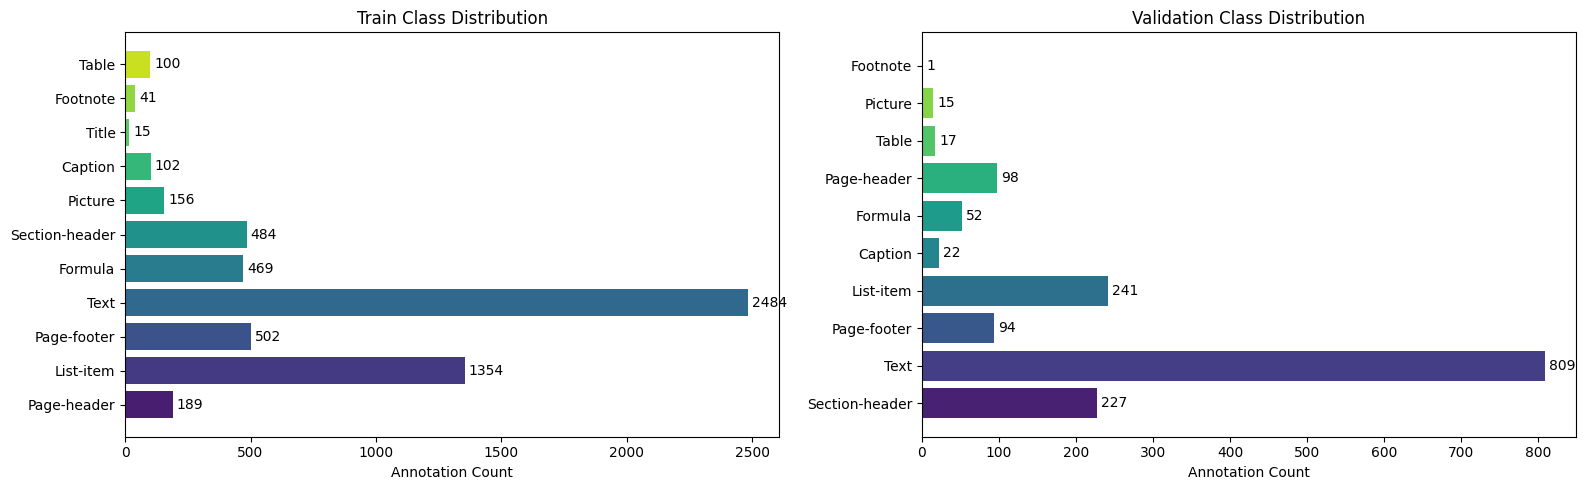

In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (title, counter) in zip(axes, [("Train", train_classes), ("Validation", val_classes)]):
    if not counter:
        ax.set_title(f"{title} — no data")
        continue
    names = list(counter.keys())
    counts = list(counter.values())
    bars = ax.barh(names, counts, color=sns.color_palette("viridis", len(names)))
    ax.set_xlabel("Annotation Count")
    ax.set_title(f"{title} Class Distribution")
    ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

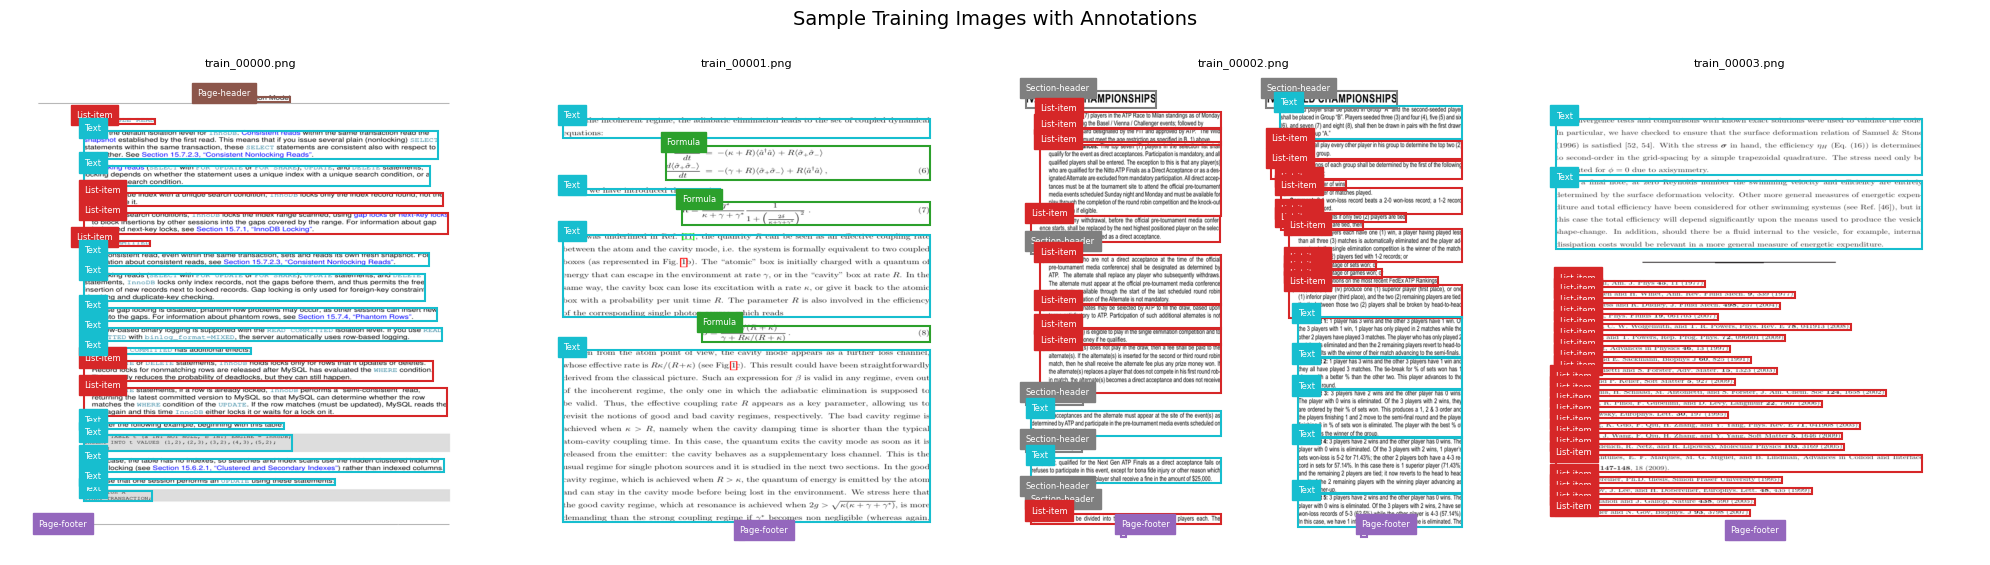

In [8]:
# Show a few sample images with bounding boxes
sample_img_dir = DATASET_DIR / "images" / "train"
sample_lbl_dir = DATASET_DIR / "labels" / "train"
sample_files = sorted(os.listdir(sample_img_dir))[:4]

# Color map for classes
cmap = plt.cm.get_cmap("tab20", NUM_CLASSES)
class_colors = {i: cmap(i) for i in range(NUM_CLASSES)}

fig, axes = plt.subplots(1, min(4, len(sample_files)), figsize=(20, 6))
if len(sample_files) == 1:
    axes = [axes]

for ax, fname in zip(axes, sample_files):
    img = Image.open(sample_img_dir / fname)
    ax.imshow(img)
    w, h = img.size

    lbl_path = sample_lbl_dir / fname.replace(".png", ".txt")
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                xc, yc, bw, bh = [float(x) for x in parts[1:]]
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=1.5, edgecolor=class_colors[cls_id], facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 2, CLASS_NAMES[cls_id], fontsize=6,
                        color="white", backgroundcolor=class_colors[cls_id])
    ax.set_title(fname, fontsize=8)
    ax.axis("off")

plt.suptitle("Sample Training Images with Annotations", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Create dataset.yaml

Ultralytics YOLO requires a YAML config pointing to image directories and listing class names.

In [9]:
dataset_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/validation",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}

yaml_path = DATASET_DIR / "dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print(f"Dataset config saved to: {yaml_path}")
print()
with open(yaml_path) as f:
    print(f.read())

Dataset config saved to: /home/appuser/Hailo-Training/datasets/doclaynet/dataset.yaml

names:
- Caption
- Footnote
- Formula
- List-item
- Page-footer
- Page-header
- Picture
- Section-header
- Table
- Text
- Title
nc: 11
path: /home/appuser/Hailo-Training/datasets/doclaynet
train: images/train
val: images/validation



## 5. Fine-Tune YOLO26n

We fine-tune the `yolo26n.pt` nano model — the smallest YOLO26 variant, optimized for edge
deployment. Transfer learning from the COCO-pretrained weights means we only need a small
dataset to get useful results.

**Training parameters:**
- `imgsz=640` — matches the Hailo-8L target resolution
- `epochs=30` — sufficient for a small dataset with transfer learning
- `batch=8` — conservative to avoid OOM on limited hardware

In [ ]:
# Training configuration
EPOCHS = 30
IMGSZ = 640
BATCH_SIZE = 8
# In Docker, worker subprocesses can crash with bus errors when /dev/shm is too small.
# Keep workers at 0 by default for maximum compatibility.
NUM_WORKERS = 2

# Prefer yolo26n.pt (this notebook's target model), fallback to yolo8n.pt if needed.
if (MODELS_DIR / "yolo26n.pt").exists():
    MODEL_PATH = MODELS_DIR / "yolo26n.pt"
elif (MODELS_DIR / "yolo8n.pt").exists():
    MODEL_PATH = MODELS_DIR / "yolo8n.pt"
else:
    MODEL_PATH = MODELS_DIR / "yolo26n.pt"

PROJECT_NAME = "doclaynet_yolo26n"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Base model not found at {MODEL_PATH}. "
        "Place yolo26n.pt (or yolo8n.pt) in /home/appuser/Hailo-Training/models/."
    )

print(f"Model: {MODEL_PATH}")
print(f"Epochs: {EPOCHS}, Image size: {IMGSZ}, Batch size: {BATCH_SIZE}")
print(f"Workers: {NUM_WORKERS} (set higher only if container SHM is sufficient)")
print(f"Dataset: {yaml_path}")

Model: /home/appuser/Hailo-Training/models/yolo26n.pt
Epochs: 30, Image size: 640, Batch size: 8
Workers: 3 (set higher only if container SHM is sufficient)
Dataset: /home/appuser/Hailo-Training/datasets/doclaynet/dataset.yaml


In [17]:
# Load base model and start training
model = YOLO(str(MODEL_PATH))

results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    workers=NUM_WORKERS,
    cache=False,
    device=0,
    project=str(WORKSPACE / "runs"),
    name=PROJECT_NAME,
    exist_ok=True,
    patience=10,       # Early stopping patience
    save=True,
    plots=True,        # Generate training plots
    verbose=True,
)

print("\nTraining complete!")

Ultralytics 8.4.26 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 2070 with Max-Q Design, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/appuser/Hailo-Training/datasets/doclaynet/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/appuser/Hailo-Training/models/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=doclaynet_yolo26n, nb

Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/queues.py", line 244, in _feed
    obj = _ForkingPickler.dumps(obj)
  File "/usr/lib/python3.10/multiprocessing/reduction.py", line 51, in dumps
    cls(buf, protocol).dump(obj)


WARNING ⚠️ DataLoader worker (pid 16842) is killed by signal: Bus error. It is possible that dataloader's workers are out of shared memory. Please try to raise your shared memory limit.
Image sizes 640 train, 640 val
Using 3 dataloader workers
Logging results to /home/appuser/Hailo-Training/runs/doclaynet_yolo26n
Starting training for 30 epochs...


  File "/venv/lib/python3.10/site-packages/torch/multiprocessing/reductions.py", line 618, in reduce_storage
    fd, size = storage._share_fd_cpu_()
  File "/venv/lib/python3.10/site-packages/torch/storage.py", line 437, in wrapper
    return fn(self, *args, **kwargs)



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  File "/venv/lib/python3.10/site-packages/torch/storage.py", line 512, in _share_fd_cpu_
    return super()._share_fd_cpu_(*args, **kwargs)
RuntimeError: unable to write to file </torch_16831_1150127820_18>: No space left on device (28)
ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 

       1/30      1.83G      3.256      5.168    0.03868        224        640: 16% ━╸────────── 10/63 3.8it/s 9.4s<14.1s


KeyboardInterrupt: 

## 6. Training Metrics & Visualization

In [ ]:
# Locate training results
train_dir = WORKSPACE / "runs" / PROJECT_NAME
results_csv = train_dir / "results.csv"

if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    print(f"Training ran for {len(df)} epochs.")
    print(f"\nFinal metrics:")
    print(df.iloc[-1].to_string())
else:
    print(f"Results CSV not found at {results_csv}")
    print("If training was interrupted, re-run the cell above.")

In [ ]:
# Plot training curves
if results_csv.exists():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Loss curves
    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    for col in loss_cols:
        label = col.replace("train/", "Train ").replace("val/", "Val ")
        if "train" in col.lower():
            axes[0, 0].plot(df["epoch"], df[col], label=label)
        else:
            axes[0, 1].plot(df["epoch"], df[col], label=label)

    axes[0, 0].set_title("Training Losses")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].set_title("Validation Losses")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)

    # mAP curves
    map_cols = [c for c in df.columns if "map" in c.lower()]
    for col in map_cols:
        axes[0, 2].plot(df["epoch"], df[col], label=col, marker=".")
    axes[0, 2].set_title("mAP Metrics")
    axes[0, 2].set_xlabel("Epoch")
    axes[0, 2].set_ylabel("mAP")
    axes[0, 2].legend(fontsize=8)
    axes[0, 2].grid(True, alpha=0.3)

    # Precision & Recall
    prec_cols = [c for c in df.columns if "precision" in c.lower()]
    rec_cols = [c for c in df.columns if "recall" in c.lower()]
    for col in prec_cols:
        axes[1, 0].plot(df["epoch"], df[col], label=col, marker=".")
    axes[1, 0].set_title("Precision")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)

    for col in rec_cols:
        axes[1, 1].plot(df["epoch"], df[col], label=col, marker=".")
    axes[1, 1].set_title("Recall")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    # Learning rate
    lr_cols = [c for c in df.columns if "lr" in c.lower()]
    for col in lr_cols:
        axes[1, 2].plot(df["epoch"], df[col], label=col)
    axes[1, 2].set_title("Learning Rate Schedule")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].legend(fontsize=8)
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle("YOLO26n Fine-Tuning on DocLayNet", fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
# Show Ultralytics-generated plots if available
plot_files = ["confusion_matrix.png", "results.png", "P_curve.png", "R_curve.png"]
available_plots = [train_dir / p for p in plot_files if (train_dir / p).exists()]

if available_plots:
    fig, axes = plt.subplots(1, len(available_plots), figsize=(7 * len(available_plots), 6))
    if len(available_plots) == 1:
        axes = [axes]
    for ax, pf in zip(axes, available_plots):
        ax.imshow(Image.open(pf))
        ax.set_title(pf.stem)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No Ultralytics plots found. They are generated after training completes.")

## 7. Validate & Run Sample Predictions

In [ ]:
# Load the best model and run validation
best_pt = train_dir / "weights" / "best.pt"
if not best_pt.exists():
    print(f"best.pt not found at {best_pt}. Using last.pt instead.")
    best_pt = train_dir / "weights" / "last.pt"

best_model = YOLO(str(best_pt))

# Run validation
val_results = best_model.val(data=str(yaml_path), imgsz=IMGSZ, batch=BATCH_SIZE)

print(f"\n{'='*50}")
print(f"Validation Results Summary")
print(f"{'='*50}")
print(f"mAP@50:      {val_results.box.map50:.4f}")
print(f"mAP@50-95:   {val_results.box.map:.4f}")
print(f"Precision:   {val_results.box.mp:.4f}")
print(f"Recall:      {val_results.box.mr:.4f}")

In [ ]:
# Run prediction on a few validation images
val_img_dir = DATASET_DIR / "images" / "validation"
val_images = sorted(os.listdir(val_img_dir))[:6]

if val_images:
    pred_results = best_model.predict(
        source=[str(val_img_dir / f) for f in val_images],
        imgsz=IMGSZ, conf=0.25, save=False, verbose=False
    )

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    for ax, result, fname in zip(axes.flat, pred_results, val_images):
        img = result.orig_img[..., ::-1]  # BGR to RGB
        ax.imshow(img)
        if result.boxes is not None:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                color = class_colors.get(cls_id, (1, 0, 0, 1))
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 3, f"{CLASS_NAMES[cls_id]} {conf:.2f}",
                        fontsize=6, color="white", backgroundcolor=color)
        ax.set_title(fname, fontsize=8)
        ax.axis("off")

    plt.suptitle("YOLO26n Predictions on Validation Set", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No validation images found.")

## 8. Save Best Model

Copy the best checkpoint to `models/` for use in the next notebook.

In [ ]:
# Copy best.pt to models directory
dest = MODELS_DIR / "best.pt"
shutil.copy2(str(best_pt), str(dest))
model_size_mb = dest.stat().st_size / (1024 * 1024)

print(f"Best model saved to: {dest}")
print(f"Model size: {model_size_mb:.1f} MB")
print(f"\nNext step: Run 02_ONNX_Export_and_Optimization.ipynb")